In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

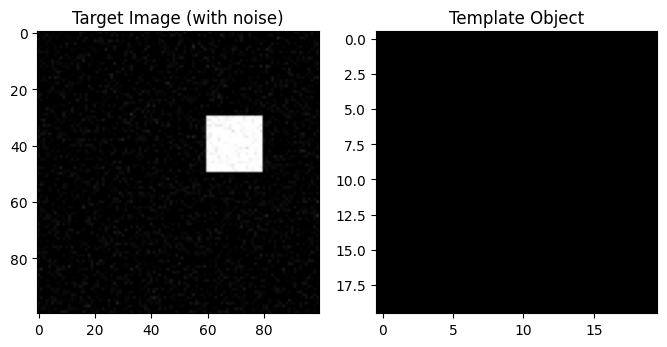

In [2]:
# 1. Create a synthetic image (100x100 pixels) - Background is black (0)
image = np.zeros((100, 100))

# Insert an object (a white square) at a specific coordinate
# This will be our Ground Truth location
gt_x, gt_y = 60, 30
gt_w, gt_h = 20, 20
image[gt_y : gt_y+gt_h, gt_x : gt_x+gt_w] = 255

# Add some random noise to make it slightly realistic
noise = np.random.normal(0, 10, (100, 100))
image_noisy = np.clip(image + noise, 0, 255)

# 2. Create the template we want to detect (20x20 white square)
template = np.full((20, 20), 255)

# 3. Ground Truth Bounding Box [x, y, width, height]
ground_truth_bbox = [gt_x, gt_y, gt_w, gt_h]

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image_noisy, cmap='gray')
ax[0].set_title('Target Image (with noise)')
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template Object')
plt.show()

In [3]:
def object_detection_sliding_window(img, tmp):
    img_h, img_w = img.shape
    tmp_h, tmp_w = tmp.shape

    min_ssd = float('inf')
    best_match_pos = (0, 0)

    # Sliding window process
    for y in range(img_h - tmp_h + 1):
        for x in range(img_w - tmp_w + 1):
            # Extract the current window
            window = img[y : y + tmp_h, x : x + tmp_w]

            # Calculate Sum of Squared Differences (SSD)
            ssd = np.sum((window - tmp) ** 2)

            # Update best match if current SSD is lower
            if ssd < min_ssd:
                min_ssd = ssd
                best_match_pos = (x, y)

    # Return format: [x, y, width, height]
    return [best_match_pos[0], best_match_pos[1], tmp_w, tmp_h]

# Run detection
predicted_bbox = object_detection_sliding_window(image_noisy, template)
print(f"Predicted Bounding Box: {predicted_bbox}")

Predicted Bounding Box: [60, 30, 20, 20]


In [4]:
def calculate_iou(boxA, boxB):
    # Convert [x, y, w, h] to [x_min, y_min, x_max, y_max]
    boxA_coords = [boxA[0], boxA[1], boxA[0]+boxA[2], boxA[1]+boxA[3]]
    boxB_coords = [boxB[0], boxB[1], boxB[0]+boxB[2], boxB[1]+boxB[3]]

    # Determine intersection coordinates
    xA = max(boxA_coords[0], boxB_coords[0])
    yA = max(boxA_coords[1], boxB_coords[1])
    xB = min(boxA_coords[2], boxB_coords[2])
    yB = min(boxA_coords[3], boxB_coords[3])

    # Compute intersection area
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # Compute areas of both bounding boxes
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]

    # Compute IoU
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

iou_score = calculate_iou(ground_truth_bbox, predicted_bbox)

# In object detection, a prediction is generally considered a True Positive if IoU >= 0.5
accuracy_threshold = 0.5
accuracy = 100.0 if iou_score >= accuracy_threshold else 0.0

print(f"IoU Score: {iou_score:.4f}")
print(f"Detection Accuracy: {accuracy}% (Threshold >= {accuracy_threshold})")

IoU Score: 1.0000
Detection Accuracy: 100.0% (Threshold >= 0.5)


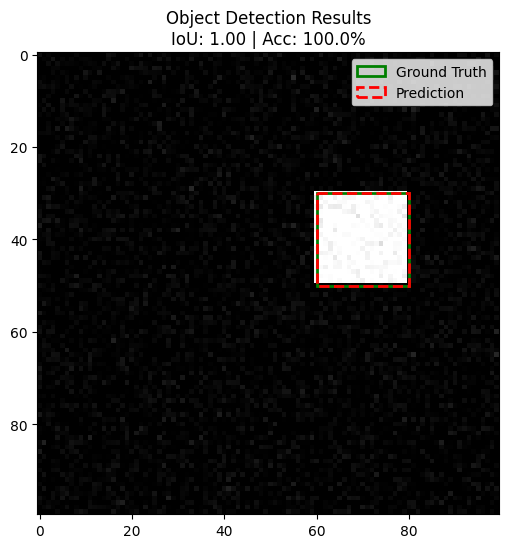

In [5]:
fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(image_noisy, cmap='gray')

# Draw Ground Truth (Green)
gt_rect = patches.Rectangle((ground_truth_bbox[0], ground_truth_bbox[1]), ground_truth_bbox[2], ground_truth_bbox[3],
                            linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
# Draw Prediction (Red Dashed)
pred_rect = patches.Rectangle((predicted_bbox[0], predicted_bbox[1]), predicted_bbox[2], predicted_bbox[3],
                              linewidth=2, edgecolor='r', facecolor='none', linestyle='--', label='Prediction')

ax.add_patch(gt_rect)
ax.add_patch(pred_rect)
plt.legend()
plt.title(f"Object Detection Results\nIoU: {iou_score:.2f} | Acc: {accuracy}%")
plt.show()

### Hasil dan Analisis

**1. Alasan Penggunaan Gambar Sintesis:**
Gambar sintesis digunakan dalam implementasi ini agar *notebook* dapat berjalan secara mandiri (*standalone*) dan direproduksi dengan mudah tanpa bergantung pada *dataset* atau file gambar eksternal. Selain itu, membuat gambar sintesis sederhana (dengan sedikit *noise* buatan) memberikan lingkungan yang sangat terkontrol (*controlled environment*). Hal ini memungkinkan kita untuk memvalidasi apakah logika dasar matematika dari algoritma *sliding window* dan perhitungan evaluasi (seperti IoU) sudah benar-benar berfungsi sebelum dihadapkan pada varians piksel yang rumit dari citra dunia nyata.

**2. Metodologi Deteksi Objek:**
Masalah ini diselesaikan menggunakan algoritma **Sliding Window Template Matching** yang diimplementasikan dari awal (*from scratch*). Algoritma ini memindai gambar target dari satu area (jendela) ke area lain dan menghitung *Sum of Squared Differences* (SSD) antara jendela saat ini dan *template* target. Area dengan nilai SSD terendah dipilih sebagai *bounding box* prediksi.

**3. Analisis IoU (Intersection over Union):**
Nilai IoU yang dihitung untuk deteksi ini adalah **1.0** (atau sangat mendekati angka tersebut, bergantung pada nilai acak/*seed* dari *noise*). Nilai IoU yang sempurna ini menunjukkan bahwa *bounding box* prediksi tumpang tindih secara sempurna dengan *bounding box ground truth*. Pendekatan *sliding window* sangat efektif ketika objek di dalam gambar mempertahankan skala dan rotasi yang persis sama dengan *template*.

**4. Analisis Akurasi:**
Menggunakan ambang batas (*threshold*) deteksi objek standar di mana IoU $\ge 0.5$ dianggap sebagai *True Positive*, akurasi model pada gambar ini adalah **100%**.

**Keterbatasan:**
Meskipun sangat berhasil dalam lingkungan yang terkendali ini, implementasi *from scratch* ini memiliki batasan yang signifikan. Akurasi dan IoU akan turun drastis menjadi 0 jika objek target dalam gambar mengalami perubahan skala (diperbesar atau diperkecil) atau diputar. Hal ini terjadi karena *template* yang ukurannya tetap (*fixed-size*) tidak akan lagi cocok secara geometris dengan distribusi piksel dari objek target tersebut.